In [3]:
import pandas as pd
import os

path = '/Users/nicholasmikhail/Desktop/UCHICAGO CLASSES/machine learning 2/project'

# First see exactly what files are there
print(os.listdir(path))

['compustat_bklabels.parquet', 'crsp_msf.parquet', 'glassdoor_text.parquet', 'master_trimodal.parquet', '00_build_master_dataset.ipynb', 'master_financial.parquet', 'compustat_company.parquet', 'crsp_linktable.parquet', 'compustat_funda.parquet', '02_baselines.ipynb', '01_extract_wrds_raw.ipynb', 'american_bankruptcy_dataset.csv', 'crsp_dsf.parquet']


In [10]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              average_precision_score, brier_score_loss)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PATH = '/Users/nicholasmikhail/Desktop/UCHICAGO CLASSES/machine learning 2/project'

TRAIN_YEARS = list(range(2003, 2018))   # 2003–2017
VAL_YEARS   = [2018, 2019]
TEST_YEARS  = list(range(2020, 2024))   # 2020–2023

In [13]:
print("Loading linktable...")
linktable = pd.read_parquet(f'{PATH}/crsp_linktable.parquet')

print("Loading bklabels...")
bklabels = pd.read_parquet(f'{PATH}/compustat_bklabels.parquet')

print("Loading dsf (price columns only)...")
dsf = pd.read_parquet(f'{PATH}/crsp_dsf.parquet',
                      columns=['permno','date','prc','ret','vol','cfacpr'])

print("Loading company...")
company = pd.read_parquet(f'{PATH}/compustat_company.parquet')

# Clean up dtypes
funda['fyear']     = funda['fyear'].astype(int)
funda['datadate']  = pd.to_datetime(funda['datadate'])
linktable['linkdt']    = pd.to_datetime(linktable['linkdt'])
linktable['linkenddt'] = pd.to_datetime(linktable['linkenddt'])
dsf['date'] = pd.to_datetime(dsf['date'])
dsf['prc']  = dsf['prc'].abs()

print(f"\nfunda:     {funda.shape}")
print(f"linktable: {linktable.shape}")
print(f"bklabels:  {bklabels.shape}")
print(f"dsf:       {dsf.shape}")
print(f"company:   {company.shape}")

Loading linktable...
Loading bklabels...
Loading dsf (price columns only)...
Loading company...

funda:     (132447, 39)
linktable: (38738, 8)
bklabels:  (387, 5)
dsf:       (29203297, 6)
company:   (45242, 20)


In [14]:
# Anchor = datadate + 90 days
anchors = (
    funda[['gvkey','fyear','datadate']]
    .query("fyear >= 2003 and fyear <= 2023")
    .dropna(subset=['datadate'])
    .copy()
)
anchors['anchor_date'] = anchors['datadate'] + pd.Timedelta(days=90)

# Resolve permno via linktable
anchors = anchors.merge(
    linktable[['gvkey','permno','linkdt','linkenddt']],
    on='gvkey', how='left'
)
anchors = anchors[
    (anchors['anchor_date'] >= anchors['linkdt']) &
    (anchors['anchor_date'] <= anchors['linkenddt'])
]
anchors = (anchors
           .sort_values(['gvkey','fyear','permno'])
           .drop_duplicates(subset=['gvkey','fyear'], keep='first')
           .drop(columns=['linkdt','linkenddt'])
           .reset_index(drop=True))

anchors['permno'] = anchors['permno'].astype(int)
print(f"Anchors with permno: {anchors.shape}")
print(anchors.head(3))

Anchors with permno: (89115, 5)
    gvkey  fyear   datadate anchor_date  permno
0  001004   2003 2004-05-31  2004-08-29   54594
1  001004   2004 2005-05-31  2005-08-29   54594
2  001004   2005 2006-05-31  2006-08-29   54594


In [15]:
# Index DSF by permno for fast lookup
dsf_idx = dsf.set_index('permno')

def compute_metrics(permno, anchor_date):
    if permno not in dsf_idx.index:
        return np.nan, np.nan

    firm = dsf_idx.loc[permno].sort_values('date')

    # Forward drawdown: 252 trading days after anchor
    fwd = firm[firm['date'] > anchor_date].head(252)
    if len(fwd) < 20:
        fwd_dd = np.nan
    else:
        adj = (fwd['prc'] / fwd['cfacpr'].replace(0, np.nan)).dropna()
        if len(adj) < 20:
            fwd_dd = np.nan
        else:
            roll_max = adj.cummax()
            fwd_dd   = ((adj - roll_max) / roll_max).min()

    # Trailing volatility: 252 trading days before anchor
    trail = firm[firm['date'] < anchor_date].tail(252)
    if len(trail) < 20:
        trail_vol = np.nan
    else:
        trail_vol = trail['ret'].dropna().std() * np.sqrt(252)

    return fwd_dd, trail_vol

print("Computing drawdown and volatility — this will take a few minutes...")
results = [compute_metrics(row.permno, row.anchor_date)
           for row in anchors.itertuples()]

anchors['drawdown'], anchors['trail_vol'] = zip(*results)

print(f"Done.")
print(f"Drawdown NaN: {anchors['drawdown'].isna().sum()}")
print(f"Vol NaN:      {anchors['trail_vol'].isna().sum()}")
print(f"\nDrawdown distribution:\n{anchors['drawdown'].describe()}")

Computing drawdown and volatility — this will take a few minutes...
Done.
Drawdown NaN: 682
Vol NaN:      526

Drawdown distribution:
count    88433.000000
mean        -0.361412
std          0.210651
min         -0.999827
25%         -0.489039
50%         -0.311932
75%         -0.196273
max         -0.000542
Name: drawdown, dtype: float64


In [16]:
bk_set = set(zip(bklabels['gvkey'], bklabels['failed_fyear'].astype(int)))

# Merge company for delisting reason
company_slim = company[['gvkey','dlrsn']].drop_duplicates('gvkey')
anchors = anchors.merge(company_slim, on='gvkey', how='left')

def adjust_drawdown(row):
    if (row['gvkey'], int(row['fyear'])) in bk_set:
        return -1.0
    return row['drawdown']

anchors['drawdown'] = anchors.apply(adjust_drawdown, axis=1)
anchors = anchors.dropna(subset=['drawdown','trail_vol']).reset_index(drop=True)

# Binary flag: worse than -30%
anchors['dd_binary'] = (anchors['drawdown'] < -0.30).astype(int)

# Cross-sectional rank within fyear
anchors['dd_rank'] = anchors.groupby('fyear')['drawdown'].rank(pct=True, ascending=True)

print(f"Final anchors: {anchors.shape}")
print(f"Drawdown worse than -30%: {anchors['dd_binary'].sum()} ({anchors['dd_binary'].mean():.1%})")
print(f"\nMean drawdown by fyear:")
print(anchors.groupby('fyear')['drawdown'].mean().round(3).to_string())

Final anchors: (87995, 10)
Drawdown worse than -30%: 45876 (52.1%)

Mean drawdown by fyear:
fyear
2003   -0.297
2004   -0.264
2005   -0.273
2006   -0.393
2007   -0.640
2008   -0.328
2009   -0.308
2010   -0.385
2011   -0.278
2012   -0.237
2013   -0.290
2014   -0.390
2015   -0.277
2016   -0.283
2017   -0.377
2018   -0.536
2019   -0.359
2020   -0.400
2021   -0.463
2022   -0.403
2023   -0.363


In [17]:
RATIO_COLS = [
    'wc_ta', 're_ta', 'ebit_ta', 'mktval_lt', 'sale_ta',  # Altman
    'lt_ta', 'ni_ta', 'lct_act', 'cfo_lt',                 # Ohlson
    'ni_at', 'lt_at', 'act_lct',                            # Zmijewski
    'gp_sale', 'ebit_sale', 'oancf_at', 'capx_at',         # margins
    'dltt_at', 'che_at'                                      # leverage / liquidity
]

def compute_ratios(row):
    eps  = 1e-6
    at   = row['at']   + eps
    sale = row['sale'] + eps
    lt   = row['lt']   + eps
    lct  = row['lct']  + eps

    return {
        # Altman
        'wc_ta'     : row['wcap']  / at,
        're_ta'     : row['re']    / at,
        'ebit_ta'   : row['ebit']  / at,
        'mktval_lt' : row['mktval'] / lt,
        'sale_ta'   : row['sale']  / at,
        # Ohlson
        'lt_ta'     : lt / at,
        'ni_ta'     : row['ni']    / at,
        'lct_act'   : lct / (row['act'] + eps),
        'cfo_lt'    : row['oancf'] / lt,
        # Zmijewski
        'ni_at'     : row['ni']    / at,
        'lt_at'     : lt / at,
        'act_lct'   : row['act']   / lct,
        # Margins / turnover
        'gp_sale'   : row['gp']    / sale,
        'ebit_sale' : row['ebit']  / sale,
        'oancf_at'  : row['oancf'] / at,
        'capx_at'   : row['capx']  / at,
        # Leverage / liquidity
        'dltt_at'   : row['dltt']  / at,
        'che_at'    : row['che']   / at,
    }

print("Computing ratios for all firm-years...")
ratio_rows = []
for _, row in funda.iterrows():
    r = compute_ratios(row)
    r['gvkey'] = row['gvkey']
    r['fyear'] = int(row['fyear'])
    ratio_rows.append(r)

ratios_df = pd.DataFrame(ratio_rows)
print(f"Ratios computed: {ratios_df.shape}")
print(ratios_df[RATIO_COLS].describe().round(3))

Computing ratios for all firm-years...
Ratios computed: (132447, 20)
           wc_ta     re_ta   ebit_ta  mktval_lt   sale_ta     lt_ta     ni_ta  \
count   104472.0  128219.0  131347.0   120713.0  131957.0  132163.0  131956.0   
unique  104399.0  128039.0  131254.0   120706.0  126583.0  132095.0  131885.0   
top          0.0       0.0       0.0        0.0       0.0       1.0       0.0   
freq        32.0     133.0      51.0        3.0    5327.0       7.0      16.0   

         lct_act    cfo_lt     ni_at     lt_at   act_lct   gp_sale  ebit_sale  \
count   104473.0  127969.0  131956.0  132163.0  104473.0  131952.0   131347.0   
unique  104391.0  127855.0  131885.0  132095.0  104355.0  126919.0   130937.0   
top          1.0       0.0       0.0       1.0       0.0       0.0        0.0   
freq        32.0      66.0      16.0       7.0      68.0    4929.0       51.0   

        oancf_at   capx_at   dltt_at    che_at  
count   128244.0  127724.0  132021.0  132437.0  
unique  128127.0  117

In [18]:
def winsorize(s, low=0.01, high=0.99):
    lo, hi = s.quantile(low), s.quantile(high)
    return s.clip(lo, hi)

# Winsorize at 1/99 within each fyear
ratios_df[RATIO_COLS] = (
    ratios_df.groupby('fyear')[RATIO_COLS]
    .transform(winsorize)
)

# Z-score within each fyear (fit on all data here, will re-fit on train only later)
ratios_df[RATIO_COLS] = (
    ratios_df.groupby('fyear')[RATIO_COLS]
    .transform(lambda s: (s - s.mean()) / (s.std() + 1e-8))
)

# Fill any remaining NaN with 0 (industry-year median after z-scoring is 0)
ratios_df[RATIO_COLS] = ratios_df[RATIO_COLS].fillna(0)

print("Winsorization and z-scoring done ✓")
print(f"Any NaN remaining: {ratios_df[RATIO_COLS].isnull().any().any()}")
print(ratios_df[RATIO_COLS].describe().round(3))

Winsorization and z-scoring done ✓
Any NaN remaining: False
            wc_ta       re_ta     ebit_ta   mktval_lt     sale_ta       lt_ta  \
count  132447.000  132447.000  132447.000  132447.000  132447.000  132447.000   
mean       -0.000       0.000      -0.000       0.000      -0.000      -0.000   
std         0.888       0.984       0.996       0.955       0.998       0.999   
min        -6.064      -7.157      -6.974      -0.538      -1.082      -1.775   
25%        -0.490       0.072      -0.007      -0.399      -0.778      -0.695   
50%         0.000       0.263       0.237      -0.297      -0.248      -0.066   
75%         0.378       0.355       0.414       0.000       0.414       0.589   
max         2.437       0.977       2.017       7.273       4.773       6.297   

            ni_ta     lct_act      cfo_lt       ni_at       lt_at     act_lct  \
count  132447.000  132447.000  132447.000  132447.000  132447.000  132447.000   
mean       -0.000      -0.000      -0.000      -

In [19]:
# For each anchor: gather fyear-4 through fyear, flatten to 90-wide vector
# 5 years × 18 ratios = 90 features

# Index ratios by gvkey+fyear for fast lookup
ratios_idx = ratios_df.set_index(['gvkey','fyear'])

def build_feature_vector(gvkey, fyear):
    rows = []
    for lag in range(4, -1, -1):  # fyear-4, fyear-3, ..., fyear
        y = fyear - lag
        key = (gvkey, y)
        if key in ratios_idx.index:
            rows.append(ratios_idx.loc[key, RATIO_COLS].values.astype(float))
        else:
            rows.append(np.zeros(len(RATIO_COLS)))  # impute missing with 0 (z-score mean)
    return np.concatenate(rows)

print("Building feature matrix...")
feat_matrix = np.vstack([
    build_feature_vector(row.gvkey, int(row.fyear))
    for row in anchors.itertuples()
])

# Column names: lag4_wc_ta, lag4_re_ta, ..., wc_ta, re_ta, ...
feat_cols = []
for lag in range(4, -1, -1):
    prefix = f'lag{lag}_' if lag > 0 else ''
    feat_cols.extend([f'{prefix}{c}' for c in RATIO_COLS])

print(f"Feature matrix shape: {feat_matrix.shape}")
print(f"Expected: ({len(anchors)}, 90)")
print(f"Any NaN: {np.isnan(feat_matrix).any()}")

Building feature matrix...
Feature matrix shape: (87995, 90)
Expected: (87995, 90)
Any NaN: False


In [20]:
X     = feat_matrix
y     = anchors['drawdown'].values
y_bin = anchors['dd_binary'].values
vol   = anchors['trail_vol'].values
yrs   = anchors['fyear'].values

TRAIN_YEARS = list(range(2003, 2018))
VAL_YEARS   = [2018, 2019]
TEST_YEARS  = list(range(2020, 2024))

train_mask = np.isin(yrs, TRAIN_YEARS)
val_mask   = np.isin(yrs, VAL_YEARS)
test_mask  = np.isin(yrs, TEST_YEARS)

X_train, y_train, y_bin_train, vol_train = X[train_mask], y[train_mask], y_bin[train_mask], vol[train_mask]
X_val,   y_val,   y_bin_val,   vol_val   = X[val_mask],   y[val_mask],   y_bin[val_mask],   vol[val_mask]
X_test,  y_test,  y_bin_test,  vol_test  = X[test_mask],  y[test_mask],  y_bin[test_mask],  vol[test_mask]

print(f"Train: {X_train.shape} | fyears 2003–2017 | mean dd: {y_train.mean():.3f}")
print(f"Val:   {X_val.shape}   | fyears 2018–2019 | mean dd: {y_val.mean():.3f}")
print(f"Test:  {X_test.shape}  | fyears 2020–2023 | mean dd: {y_test.mean():.3f}")
print(f"\nBinary label (dd < -30%):")
print(f"  Train: {y_bin_train.mean():.1%}")
print(f"  Val:   {y_bin_val.mean():.1%}")
print(f"  Test:  {y_bin_test.mean():.1%}")

Train: (60948, 90) | fyears 2003–2017 | mean dd: -0.335
Val:   (8336, 90)   | fyears 2018–2019 | mean dd: -0.446
Test:  (18711, 90)  | fyears 2020–2023 | mean dd: -0.407

Binary label (dd < -30%):
  Train: 47.3%
  Val:   70.9%
  Test:  59.5%


In [21]:
from scipy import stats

def evaluate(name, y_true, y_pred, y_true_bin, yrs_subset=None):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = mean_squared_error(y_true, y_pred) ** 0.5
    r2    = r2_score(y_true, y_pred)

    # Convert predicted drawdown to risk score (more negative = higher risk)
    risk_score = -y_pred
    # Normalize to [0,1] for brier score
    rs_min, rs_max = risk_score.min(), risk_score.max()
    risk_prob = (risk_score - rs_min) / (rs_max - rs_min + 1e-8)

    pr_auc = average_precision_score(y_true_bin, risk_score)
    brier  = brier_score_loss(y_true_bin, risk_prob)

    # Spearman rank correlation
    spearman = stats.spearmanr(y_true, y_pred).statistic

    # Top-decile precision: of firms we predict worst 10%, how many actually were worst 10%
    threshold      = np.percentile(y_pred, 10)
    top_decile_mask = y_pred <= threshold
    top_decile_prec = y_true_bin[top_decile_mask].mean() if top_decile_mask.sum() > 0 else np.nan

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  MAE              : {mae:.4f}")
    print(f"  RMSE             : {rmse:.4f}")
    print(f"  R²               : {r2:.4f}")
    print(f"  PR-AUC (@-30%)   : {pr_auc:.4f}")
    print(f"  Brier Score      : {brier:.4f}")
    print(f"  Spearman ρ       : {spearman:.4f}")
    print(f"  Top-decile prec  : {top_decile_prec:.4f}")

    return {
        'model': name, 'mae': mae, 'rmse': rmse, 'r2': r2,
        'pr_auc': pr_auc, 'brier': brier,
        'spearman': spearman, 'top_decile_prec': top_decile_prec
    }

results = []
print("Evaluation helper ready ✓")

Evaluation helper ready ✓


In [22]:
from sklearn.linear_model import LinearRegression

# Fit on train only
vol_train_2d = vol_train.reshape(-1, 1)
vol_val_2d   = vol_val.reshape(-1, 1)
vol_test_2d  = vol_test.reshape(-1, 1)

vol_model = LinearRegression()
vol_model.fit(vol_train_2d, y_train)

print(f"Volatility model: drawdown = {vol_model.coef_[0]:.4f} × vol + {vol_model.intercept_:.4f}")

y_pred_vol_val  = vol_model.predict(vol_val_2d)
y_pred_vol_test = vol_model.predict(vol_test_2d)

results.append(evaluate("Baseline 0 — Vol Only (Val)",  y_val,  y_pred_vol_val,  y_bin_val))
results.append(evaluate("Baseline 0 — Vol Only (Test)", y_test, y_pred_vol_test, y_bin_test))

Volatility model: drawdown = -0.2282 × vol + -0.2310

  Baseline 0 — Vol Only (Val)
  MAE              : 0.1805
  RMSE             : 0.2274
  R²               : -0.1623
  PR-AUC (@-30%)   : 0.7973
  Brier Score      : 0.6042
  Spearman ρ       : 0.1747
  Top-decile prec  : 0.9341

  Baseline 0 — Vol Only (Test)
  MAE              : 0.1532
  RMSE             : 0.2091
  R²               : 0.1664
  PR-AUC (@-30%)   : 0.8689
  Brier Score      : 0.5732
  Spearman ρ       : 0.6477
  Top-decile prec  : 0.9647


In [23]:
from sklearn.linear_model import RidgeCV

# Cross-validate alpha on train only
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

ridge = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_absolute_error')
ridge.fit(X_train, y_train)

print(f"Best alpha: {ridge.alpha_}")

y_pred_ridge_val  = ridge.predict(X_val)
y_pred_ridge_test = ridge.predict(X_test)

results.append(evaluate("Baseline 1 — Ridge (Val)",  y_val,  y_pred_ridge_val,  y_bin_val))
results.append(evaluate("Baseline 1 — Ridge (Test)", y_test, y_pred_ridge_test, y_bin_test))

Best alpha: 1000.0

  Baseline 1 — Ridge (Val)
  MAE              : 0.1779
  RMSE             : 0.2278
  R²               : -0.1662
  PR-AUC (@-30%)   : 0.8310
  Brier Score      : 0.4041
  Spearman ρ       : 0.3053
  Top-decile prec  : 0.9628

  Baseline 1 — Ridge (Test)
  MAE              : 0.1552
  RMSE             : 0.2027
  R²               : 0.2172
  PR-AUC (@-30%)   : 0.8474
  Brier Score      : 0.3369
  Spearman ρ       : 0.5820
  Top-decile prec  : 0.9696


In [24]:
import xgboost as xgb

param_grid = [
    {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.8},
    {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.8},
    {'max_depth': 3, 'learning_rate': 0.10, 'n_estimators': 100, 'subsample': 0.8},
    {'max_depth': 4, 'learning_rate': 0.10, 'n_estimators': 100, 'subsample': 0.8},
]

best_model, best_mae, best_params = None, np.inf, None

for params in param_grid:
    m = xgb.XGBRegressor(**params, random_state=42, verbosity=0)
    m.fit(X_train, y_train)
    mae = mean_absolute_error(y_val, m.predict(X_val))
    print(f"  {params}  Val MAE={mae:.4f}")
    if mae < best_mae:
        best_mae, best_model, best_params = mae, m, params

print(f"\nBest params: {best_params}")

y_pred_xgb_val  = best_model.predict(X_val)
y_pred_xgb_test = best_model.predict(X_test)

results.append(evaluate("Baseline 2 — XGBoost (Val)",  y_val,  y_pred_xgb_val,  y_bin_val))
results.append(evaluate("Baseline 2 — XGBoost (Test)", y_test, y_pred_xgb_test, y_bin_test))

  {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.8}  Val MAE=0.1680
  {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.8}  Val MAE=0.1666
  {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.8}  Val MAE=0.1680
  {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.8}  Val MAE=0.1657

Best params: {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.8}

  Baseline 2 — XGBoost (Val)
  MAE              : 0.1657
  RMSE             : 0.2115
  R²               : -0.0053
  PR-AUC (@-30%)   : 0.8535
  Brier Score      : 0.3822
  Spearman ρ       : 0.3923
  Top-decile prec  : 0.9664

  Baseline 2 — XGBoost (Test)
  MAE              : 0.1393
  RMSE             : 0.1770
  R²               : 0.4031
  PR-AUC (@-30%)   : 0.8728
  Brier Score      : 0.2724
  Spearman ρ       : 0.6520
  Top-decile prec  : 0.9728



=== TEST SET RESULTS ===
                          mae    rmse      r2  pr_auc   brier  spearman  top_decile_prec
model                                                                                   
Baseline 0 — Vol Only  0.1532  0.2091  0.1664  0.8689  0.5732    0.6477           0.9647
Baseline 1 — Ridge     0.1552  0.2027  0.2172  0.8474  0.3369    0.5820           0.9696
Baseline 2 — XGBoost   0.1393  0.1770  0.4031  0.8728  0.2724    0.6520           0.9728


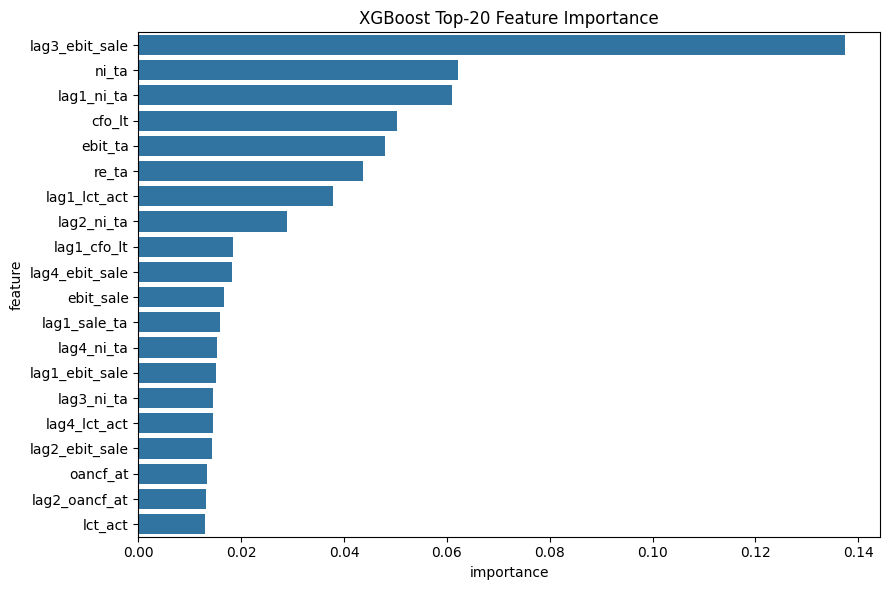

           feature  importance
31  lag3_ebit_sale    0.137366
78           ni_ta    0.062174
60      lag1_ni_ta    0.060953
80          cfo_lt    0.050298
74         ebit_ta    0.047970
73           re_ta    0.043695
61    lag1_lct_act    0.037890
42      lag2_ni_ta    0.028934
62     lag1_cfo_lt    0.018402
13  lag4_ebit_sale    0.018299
85       ebit_sale    0.016592
58    lag1_sale_ta    0.015777
6       lag4_ni_ta    0.015331
67  lag1_ebit_sale    0.015134
24      lag3_ni_ta    0.014510
7     lag4_lct_act    0.014486
49  lag2_ebit_sale    0.014393
86        oancf_at    0.013436
50   lag2_oancf_at    0.013185
79         lct_act    0.012925


In [25]:
# Summary table — test set only
summary = pd.DataFrame([r for r in results if 'Test' in r['model']])
summary['model'] = summary['model'].str.replace(' \(Test\)', '', regex=True)
summary = summary.set_index('model')
print("\n=== TEST SET RESULTS ===")
print(summary.round(4).to_string())

# Feature importance
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'feature': feat_cols, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_df, x='importance', y='feature')
plt.title('XGBoost Top-20 Feature Importance')
plt.tight_layout()
plt.savefig(f'{PATH}/feature_importance.png', dpi=150)
plt.show()
print(feat_df.to_string())

In [26]:
# Save anchors with targets
anchors.to_parquet(f'{PATH}/anchors.parquet', index=False)

# Save feature matrix
feat_df_out = pd.DataFrame(feat_matrix, columns=feat_cols)
feat_df_out['gvkey'] = anchors['gvkey'].values
feat_df_out['fyear'] = anchors['fyear'].values
feat_df_out.to_parquet(f'{PATH}/features.parquet', index=False)

# Save summary results
summary.to_csv(f'{PATH}/baseline_results.csv')

print("Saved:")
print(f"  anchors.parquet     — {anchors.shape}")
print(f"  features.parquet    — {feat_df_out.shape}")
print(f"  baseline_results.csv")
print("\nDone ✓ Ready to share with team.")

Saved:
  anchors.parquet     — (87995, 10)
  features.parquet    — (87995, 92)
  baseline_results.csv

Done ✓ Ready to share with team.
